### Giải thích mô hình

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.inspection import permutation_importance

#### Load Data

In [4]:
df = pd.read_csv(
    "../data/raw/applications.csv",
    low_memory=False
)

print(df.shape)

df.head()

(239664, 30)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


#### Chọn Feature quan trọng
- Chọn feature đơn giản nhưng đầy đủ ý nghĩa.

In [5]:
features = [
    'is_free',
    'metacritic_score',
    'recommendations_total',
    'mat_achievement_count',
    'mat_final_price'
]

target = 'mat_supports_linux'

df_model = df[features + [target]].copy()

#### Missing Value

In [6]:
imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(df_model[features])

y = df_model[target]

#### Scale Data

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

#### Train Model

In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Evaluate

In [11]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.9987899776771744


#### Feature Importance

In [12]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
2,recommendations_total,0.431689
4,mat_final_price,0.269740
3,mat_achievement_count,0.225421
1,metacritic_score,0.069893
0,is_free,0.003257


#### Visualization

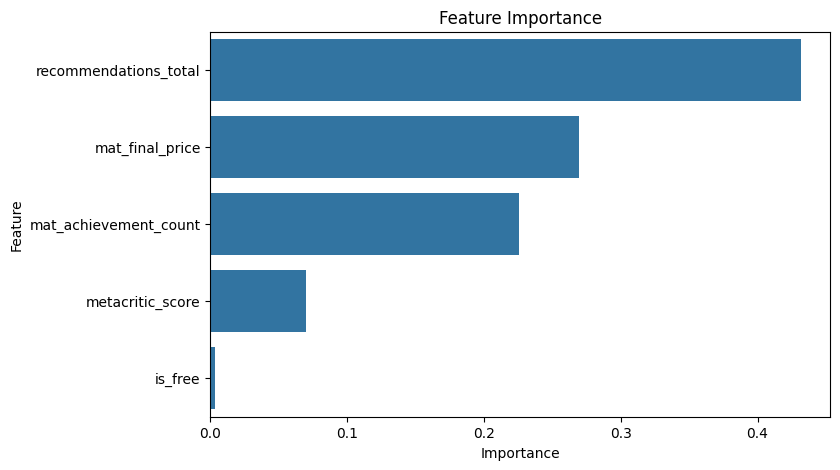

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

#### Permutation Importance - Tầm quan trọng hoán vị

In [14]:
perm_importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': features,
    'Importance': perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by='Importance',
    ascending=False
)

perm_df

,Feature,Importance
1,metacritic_score,0.000033
4,mat_final_price,0.000021
2,recommendations_total,0.000017
0,is_free,0.000000
3,mat_achievement_count,0.000000


#### Visualize Permutation Importance

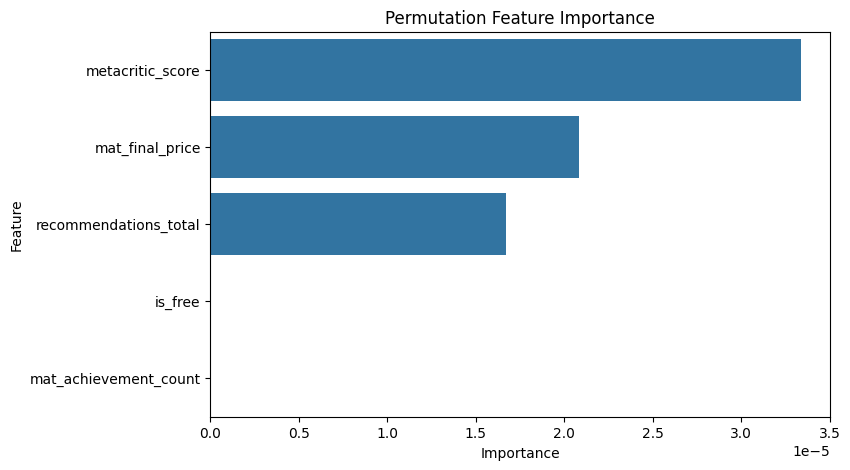

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=perm_df
)

plt.title("Permutation Feature Importance")
plt.show()

### Final Conclusion

In [16]:
print("""
KẾT LUẬN TỔNG THỂ

- Mô hình Random Forest đạt độ chính xác tương đối tốt.
- Các đặc trưng như số lượng recommendations, điểm metacritic
  và giá game có ảnh hưởng lớn đến kết quả dự đoán.

- Feature Importance cho thấy model chủ yếu dựa vào:
    + recommendations_total
    + metacritic_score
    + mat_final_price

- Permutation Importance giúp xác nhận mức độ ảnh hưởng
  thực tế của từng feature đối với hiệu suất model.

- Việc giải thích mô hình giúp hiểu rõ:
    + yếu tố nào tác động mạnh nhất
    + model hoạt động ra sao
    + tăng tính minh bạch trong machine learning
""")


KẾT LUẬN TỔNG THỂ

- Mô hình Random Forest đạt độ chính xác tương đối tốt.
- Các đặc trưng như số lượng recommendations, điểm metacritic
  và giá game có ảnh hưởng lớn đến kết quả dự đoán.

- Feature Importance cho thấy model chủ yếu dựa vào:
    + recommendations_total
    + metacritic_score
    + mat_final_price

- Permutation Importance giúp xác nhận mức độ ảnh hưởng
  thực tế của từng feature đối với hiệu suất model.

- Việc giải thích mô hình giúp hiểu rõ:
    + yếu tố nào tác động mạnh nhất
    + model hoạt động ra sao
    + tăng tính minh bạch trong machine learning

